In [13]:
# Importing necessary libraries
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn import Module, Embedding, RNN, Linear

In [14]:
# Loading the dataset
# Note: Ensure this path is correct for your environment
df = pd.read_csv(filepath_or_buffer="data/question answers.csv")
df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [15]:
# Tokenizing functions
def preprocess(text: str) -> list:
    text = text.lower()
    text = text.replace("?", "").replace("'", "")
    return text.split(sep=" ")

def text_to_indices(text, vocab):
    indexed_text = []
    for token in preprocess(text):
        indexed_text.append(vocab.get(token, vocab['<UNK>']))
    return indexed_text

In [16]:
# Vocabulary building
vocab = {'<UNK>': 0}

def build_vocab(row):
    merged_tokens = preprocess(row['question']) + preprocess(row['answer'])
    for token in merged_tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

df.apply(build_vocab, axis=1)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 324


In [17]:
# FIX 1: Correct pad_sequences logic
def pad_sequences(text_tensor: torch.Tensor, max_len: int, mode: str = 'post') -> torch.Tensor:
    pad_size = max_len - len(text_tensor)
    if pad_size <= 0:
        return text_tensor[:max_len]
    
    if mode == 'post':
        # Pad on the right
        return F.pad(input=text_tensor, pad=[0, pad_size], mode='constant', value=0)
    else:
        # Pad on the left (Pre-padding)
        return F.pad(input=text_tensor, pad=[pad_size, 0], mode='constant', value=0)

In [18]:
# FIX 2: Compute max lengths and pad both Question and Answer
class CustomDataset(Dataset):
    def __init__(self, df, vocab, mode):
        super().__init__()
        self.df = df
        self.vocab = vocab
        self.mode = mode
        
        # Find global max lengths across the dataframe
        self.max_q_len = df["question"].apply(preprocess).str.len().max()
        self.max_a_len = df["answer"].apply(preprocess).str.len().max()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        doc = self.df.iloc[index]
        
        q_indices = text_to_indices(doc["question"], self.vocab)
        a_indices = text_to_indices(doc["answer"], self.vocab)
        
        # Pad question using the specified mode (pre/post)
        question = pad_sequences(torch.tensor(q_indices), self.max_q_len, mode=self.mode)
        
        # Always pad answer (usually post-pad for labels is fine, as we just need equal size)
        answer = pad_sequences(torch.tensor(a_indices), self.max_a_len, mode='post')
        
        return question, answer

In [19]:
# Building Dataloaders
post_padded_dataset = CustomDataset(df=df, vocab=vocab, mode="post")
pre_padded_dataset = CustomDataset(df=df, vocab=vocab, mode="pre")

post_padded_dataloader = DataLoader(dataset=post_padded_dataset, batch_size=5, shuffle=True)
pre_padded_dataloader = DataLoader(dataset=pre_padded_dataset, batch_size=5, shuffle=True)

In [20]:
# RNN Model Building
class SimpleRNN(Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = Embedding(num_embeddings=vocab_size, embedding_dim=50)
        self.rnn = RNN(input_size=50, hidden_size=64, batch_first=True)
        self.linear = Linear(in_features=64, out_features=vocab_size)

    def forward(self, question):
        embedded = self.embedding(question)
        # rnn returns (outputs, final_hidden_state)
        # final_hidden_state shape: (num_layers, batch, hidden_size)
        _, final = self.rnn(embedded)
        return self.linear(final.squeeze(0))

In [21]:
# FIX 3: Unique models and unique optimizers
post_model = SimpleRNN(len(vocab))
pre_model = SimpleRNN(len(vocab))

criterion = torch.nn.CrossEntropyLoss()
lr = 0.001

post_optimizer = torch.optim.Adam(post_model.parameters(), lr=lr)
pre_optimizer = torch.optim.Adam(pre_model.parameters(), lr=lr)

In [22]:
epochs = 50
post_losses = []
pre_losses = []

print("Starting Post-Padding Training...")
for epoch in range(epochs):
    batch_loss = 0
    for question, answer in post_padded_dataloader:
        post_optimizer.zero_grad()
        output = post_model(question)
        # answer is (batch, max_a_len). We target the first token of the answer for simplicity
        loss = criterion(output, answer[:, 0])
        loss.backward()
        post_optimizer.step()
        batch_loss += loss.item()
    post_losses.append(batch_loss / len(post_padded_dataloader))

Starting Post-Padding Training...


In [23]:
print("Starting Pre-Padding Training...")
for epoch in range(epochs):
    batch_loss = 0
    for question, answer in pre_padded_dataloader:
        pre_optimizer.zero_grad()
        output = pre_model(question)
        loss = criterion(output, answer[:, 0])
        loss.backward()
        pre_optimizer.step()
        batch_loss += loss.item()
    pre_losses.append(batch_loss / len(pre_padded_dataloader))

print("Training Complete.")

Starting Pre-Padding Training...
Training Complete.


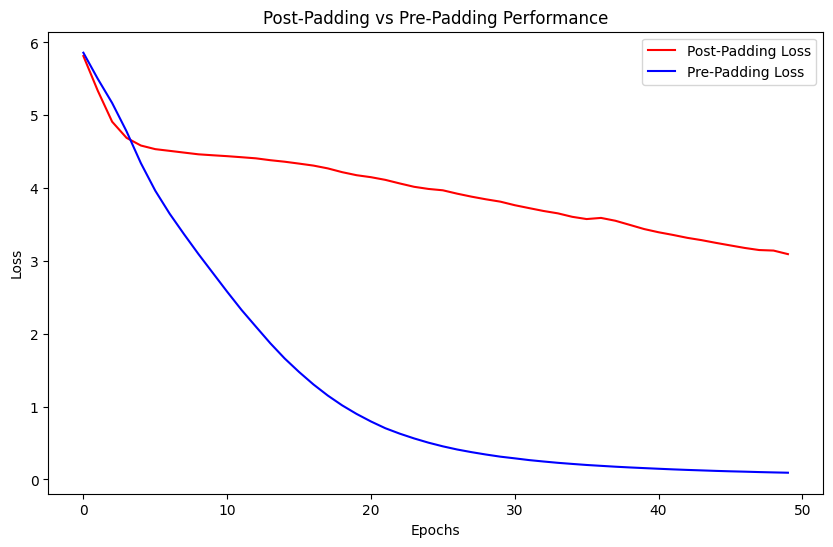

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(post_losses, label="Post-Padding Loss", color='red')
plt.plot(pre_losses, label="Pre-Padding Loss", color='blue')
plt.title("Post-Padding vs Pre-Padding Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()